# 链式法则与反向传播直觉 - 可视化

本 Notebook 生成三张图：
1. 复合函数链路图（x→z→a→L）
2. Sigmoid 与其导数曲线
3. 两层网络反向传播梯度流示意

输出目录：`assets/`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

assets_dir = Path.cwd() / 'assets'
assets_dir.mkdir(parents=True, exist_ok=True)
assets_dir

WindowsPath('D:/BBFEC-FRONT/RL-AND-RL/01_数学基础/01_微积分/assets')

## 图1：复合函数链路图

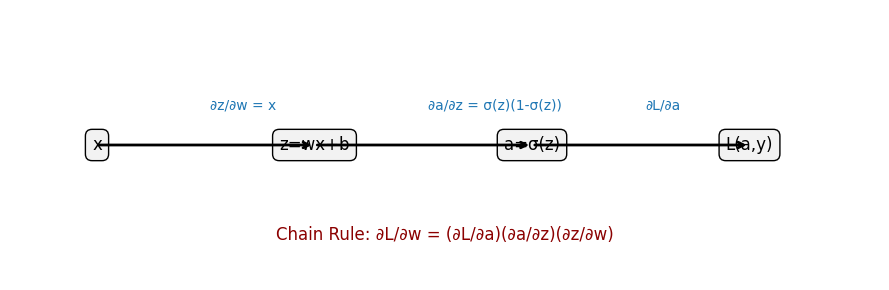

In [2]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.axis('off')

nodes = {
    'x': (0.10, 0.5),
    'z=wx+b': (0.35, 0.5),
    'a=σ(z)': (0.60, 0.5),
    'L(a,y)': (0.85, 0.5),
}

for label, (x, y) in nodes.items():
    ax.text(x, y, label, ha='center', va='center', fontsize=12,
            bbox=dict(boxstyle='round,pad=0.4', fc='#f2f2f2', ec='black'))

# arrows
arrow = dict(arrowstyle='->', lw=2)
ax.annotate('', xy=nodes['z=wx+b'], xytext=nodes['x'], arrowprops=arrow)
ax.annotate('', xy=nodes['a=σ(z)'], xytext=nodes['z=wx+b'], arrowprops=arrow)
ax.annotate('', xy=nodes['L(a,y)'], xytext=nodes['a=σ(z)'], arrowprops=arrow)

# derivative labels
ax.text(0.23, 0.63, '∂z/∂w = x', fontsize=10, color='tab:blue')
ax.text(0.48, 0.63, '∂a/∂z = σ(z)(1-σ(z))', fontsize=10, color='tab:blue')
ax.text(0.73, 0.63, '∂L/∂a', fontsize=10, color='tab:blue')

ax.text(0.5, 0.15, 'Chain Rule: ∂L/∂w = (∂L/∂a)(∂a/∂z)(∂z/∂w)',
        ha='center', fontsize=12, color='darkred')

plt.tight_layout()
plt.savefig(assets_dir / '04_chain_graph.png', dpi=160)
plt.show()

## 图2：Sigmoid 与其导数

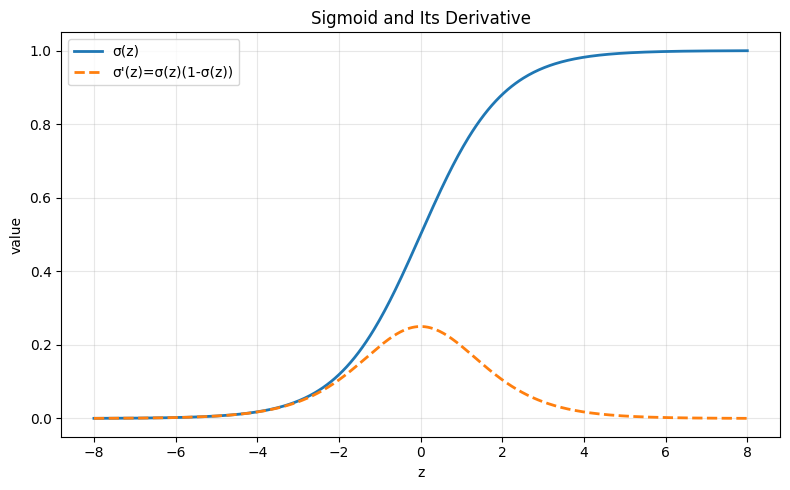

In [3]:
z = np.linspace(-8, 8, 500)
sig = 1 / (1 + np.exp(-z))
dsig = sig * (1 - sig)

plt.figure(figsize=(8, 5))
plt.plot(z, sig, label='σ(z)', linewidth=2)
plt.plot(z, dsig, '--', label="σ'(z)=σ(z)(1-σ(z))", linewidth=2)
plt.title('Sigmoid and Its Derivative')
plt.xlabel('z')
plt.ylabel('value')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(assets_dir / '05_sigmoid_and_derivative.png', dpi=160)
plt.show()

## 图3：两层网络梯度流示意

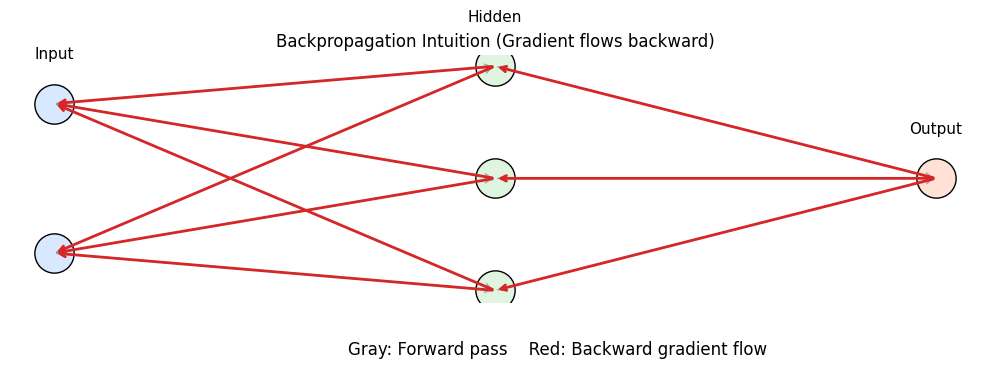

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

# layer positions
inp = [(0.1, 0.7), (0.1, 0.3)]
hid = [(0.45, 0.8), (0.45, 0.5), (0.45, 0.2)]
out = [(0.8, 0.5)]

def draw_nodes(nodes, color, label=None):
    for i, (x, y) in enumerate(nodes):
        ax.scatter(x, y, s=800, c=color, edgecolors='black', zorder=3)
        if label and i == 0:
            ax.text(x, y+0.12, label, ha='center', fontsize=11)

draw_nodes(inp, '#d8e8ff', 'Input')
draw_nodes(hid, '#dff5df', 'Hidden')
draw_nodes(out, '#ffe1d6', 'Output')

# forward edges
for x1, y1 in inp:
    for x2, y2 in hid:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=1.2, color='gray', alpha=0.6))
for x1, y1 in hid:
    for x2, y2 in out:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=1.2, color='gray', alpha=0.6))

# backward gradient flow
for x1, y1 in out:
    for x2, y2 in hid:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=2.0, color='tab:red'))
for x1, y1 in hid:
    for x2, y2 in inp:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='->', lw=2.0, color='tab:red'))

ax.text(0.5, 0.03, 'Gray: Forward pass    Red: Backward gradient flow', ha='center', fontsize=12)
ax.set_title('Backpropagation Intuition (Gradient flows backward)')

plt.tight_layout()
plt.savefig(assets_dir / '06_backprop_flow.png', dpi=160)
plt.show()

### 输出文件
- `assets/04_chain_graph.png`
- `assets/05_sigmoid_and_derivative.png`
- `assets/06_backprop_flow.png`